# Assignment 01: Part-of-Speech (POS) Extraction from a News Article

**Name:** Kiran

**Objective:** Apply NLP techniques to identify and extract Nouns and Verbs from an English news article using spaCy's POS tagger.

**Pipeline:**
1. Load the article text file
2. Run spaCy's POS tagger over the text
3. Filter tokens tagged as Nouns (`NOUN`, `PROPN`) and Verbs (`VERB`)
4. Export the results to a CSV file (`Word`, `POS_Tag` columns)


## 1. Install & Import Libraries

We use [spaCy](https://spacy.io/) with the small English pipeline `en_core_web_sm`, which includes a POS tagger trained on English text.

In [1]:
# Run this cell once if spaCy / the English model are not yet installed
# !pip install spacy
# !python -m spacy download en_core_web_sm


In [9]:
import spacy
import pandas as pd

# Load the small English pipeline (tokenizer, tagger, parser, NER, etc.)
nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline loaded:", nlp.pipe_names)


spaCy pipeline loaded: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## 2. Load the News Article

The article was downloaded from a news source and saved as a plain text file: `article.txt`.


In [10]:
ARTICLE_PATH = "article.txt"

with open(ARTICLE_PATH, "r", encoding="utf-8") as f:
    article_text = f.read()

print(f"Article length: {len(article_text)} characters")
print("\n--- Preview ---\n")
print(article_text[:500], "...")


Article length: 2096 characters

--- Preview ---

Global Leaders Gather in Geneva to Discuss Climate Financing

Geneva, Switzerland - Representatives from more than sixty countries met in Geneva on Thursday to negotiate a new round of climate financing aimed at helping developing nations transition to renewable energy. The three-day summit, organized by the United Nations Environment Programme, brought together government ministers, business executives, and scientists to discuss funding mechanisms for solar and wind projects across Africa and S ...


## 3. Perform POS Tagging

We pass the full text through the spaCy pipeline. Each resulting `token` carries a coarse-grained POS tag in `token.pos_` (e.g. `NOUN`, `VERB`, `PROPN`, `ADJ`, ...).

In [11]:
doc = nlp(article_text)

# Quick look at the first 20 tagged tokens
for token in list(doc)[:20]:
    print(f"{token.text:<15} {token.pos_}")


Global          ADJ
Leaders         PROPN
Gather          PROPN
in              ADP
Geneva          PROPN
to              ADP
Discuss         PROPN
Climate         PROPN
Financing       PROPN


              SPACE
Geneva          PROPN
,               PUNCT
Switzerland     PROPN
-               PUNCT
Representatives PROPN
from            ADP
more            ADJ
than            ADP
sixty           NUM
countries       NOUN


## 4. Extract Nouns and Verbs

We keep tokens tagged as:
- `NOUN` — common nouns
- `PROPN` — proper nouns (names of people, places, organizations)
- `VERB` — verbs

Punctuation, stop words that aren't nouns/verbs, and other POS categories (adjectives, adverbs, etc.) are excluded. We also skip pure whitespace/punctuation tokens.


In [12]:
target_tags = {"NOUN", "PROPN", "VERB"}

extracted = []
for token in doc:
    if token.pos_ in target_tags and token.is_alpha:
        extracted.append({"Word": token.text, "POS_Tag": token.pos_})

df = pd.DataFrame(extracted)
print(f"Total nouns/verbs extracted: {len(df)}")
df.head(15)


Total nouns/verbs extracted: 166


,Word,POS_Tag
0,Leaders,PROPN
1,Gather,PROPN
2,Geneva,PROPN
3,Discuss,PROPN
4,Climate,PROPN
5,Financing,PROPN
6,Geneva,PROPN
7,Switzerland,PROPN
8,Representatives,PROPN
9,countries,NOUN


### Summary counts by tag

POS_Tag
NOUN     84
VERB     47
PROPN    35
Name: count, dtype: int64


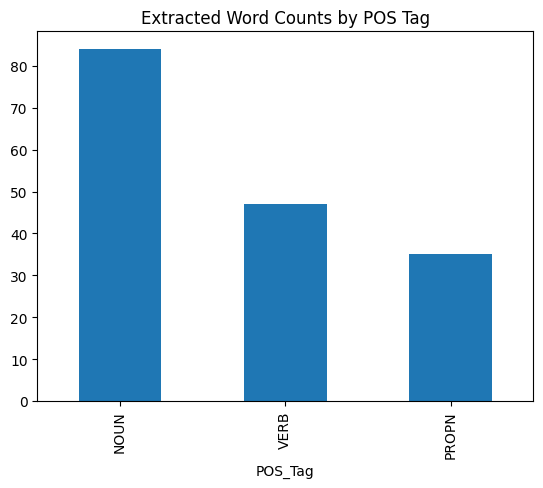

In [13]:
summary = df["POS_Tag"].value_counts()
print(summary)
summary.plot(kind="bar", title="Extracted Word Counts by POS Tag");


## 5. Export to CSV

In [14]:
OUTPUT_CSV = "KiranKhatri_POS_01.csv"  # rename with your own name before submitting

df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(df)} rows to {OUTPUT_CSV}")


Saved 166 rows to KiranKhatri_POS_01.csv


## 6. Conclusion

This notebook loaded a news article, tagged every token with its part of speech using spaCy's statistical POS tagger, filtered for nouns (`NOUN`, `PROPN`) and verbs (`VERB`), and exported the results to a CSV file with `Word` and `POS_Tag` columns, as required by the assignment.
